In [1]:
import pandas as pd
import geopandas as gpd
import networkx as nx
import osmnx as ox
import matplotlib.pyplot as plt

## __Update 28 bus stop snaps to SERVICE LINKS__

In [46]:
bus_stops_ox = gpd.read_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Transporte Publico/Snapped/ox_nearestEdge/bus_stops_snapped_ox.shp')
bus_stops_service = gpd.read_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Transporte Publico/Snapped/ox_nearestEdge/service/bus_stops_snapped_service.shp')
bus_stops_living_street = gpd.read_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Transporte Publico/Snapped/ox_nearestEdge/living street/bus_stops_snapped_living_street.shp')

In [49]:
cols_to_update = ['NearestNod', 'NearestN_1', 'NearestEdg', 'SnapDist_m', 'NearestLin', 'RelPosOnLi', 'FromNodeNo', 'ToNodeNo', 'NearestL_1']

In [50]:
# Reset ID
bus_stops_ox = bus_stops_ox.set_index('id')
bus_stops_service = bus_stops_service.set_index('id')
bus_stops_living_street = bus_stops_living_street.set_index('id')

# Update bus_stops_ox with the new columns from bus_stops_service and bus_stops_living_street
bus_stops_ox.update(bus_stops_service[cols_to_update])
bus_stops_ox.update(bus_stops_living_street[cols_to_update])
bus_stops_ox.reset_index(inplace=True)

In [56]:
bus_stops_ox['stop_id'] = range(1, len(bus_stops_ox) + 1)
bus_stops_ox

,id,mobiliario,iluminaci,señal_ver,señal_hor,banqueta,vegetació,ruta_1,ruta_2,ruta_3,...,NearestN_1,NearestEdg,SnapDist_m,NearestLin,RelPosOnLi,FromNodeNo,ToNodeNo,NearestL_1,geometry,stop_id
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Troncal 13A Solidaridad,Troncal 13B Solidaridad,T13A-C02,...,3304,"(1771858665, 8778745267, 0)",8.207127,9238,0.116142,3304,30379,secondary,POINT (680976.456 2272736.641),1
1,2.0,0.0,0.0,0.0,0.0,0.0,0.0,Troncal 19 Periferico,C19,C46-V1,...,2340,"(1677124239, 1700484749, 0)",8.441228,4352,0.817699,1495,2340,primary,POINT (681483.254 2280845.501),2
2,3.0,0.0,1.0,0.0,0.0,1.0,0.0,T21 Zapotlanejo,T21-C01,R1-Tepetates,...,24811,"(8407044724, 8407044728, 0)",6.982640,65242,0.850051,24808,24811,residential,POINT (700561.553 2281164.022),3
3,4.0,0.0,1.0,0.0,0.0,1.0,0.0,T21 Zapotlanejo,T21-C01,R1-Tepetates,...,2947,"(1746083332, 8778413347, 0)",10.527186,8267,0.339513,2947,30220,secondary,POINT (700707.084 2281320.114),4
4,5.0,0.0,1.0,0.0,0.0,1.0,0.0,T21 Zapotlanejo,T21-C01,R1-Tepetates,...,2948,"(1746090115, 1746083335, 0)",4.600218,8384,0.595657,2997,2948,secondary,POINT (700907.289 2281378.235),5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12513,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,...,16245,"(6322033098, 6322033110, 0)",8.663037,49413,0.110336,18239,18245,primary,POINT (699396.25 2280168.108),12514
12514,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,...,25555,"(6322039422, 8414023283, 0)",1.691836,49451,0.920860,18255,25555,primary,POINT (699836.994 2280555.417),12515
12515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,...,2959,"(1746083353, 1746083377, 0)",2.215223,8288,0.801377,2957,2959,secondary,POINT (701461.661 2281478.528),12516
12516,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,...,3072,"(1746195132, 1746293814, 0)",5.281715,8511,0.772637,3047,3072,tertiary,POINT (701108.581 2281835.306),12517


In [57]:
bus_stops_ox.to_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Transporte Publico/Snapped/ox_nearestEdge/bus_stops_snapped_ox.shp')

## __Histograma de distancia SP a NearestLink__

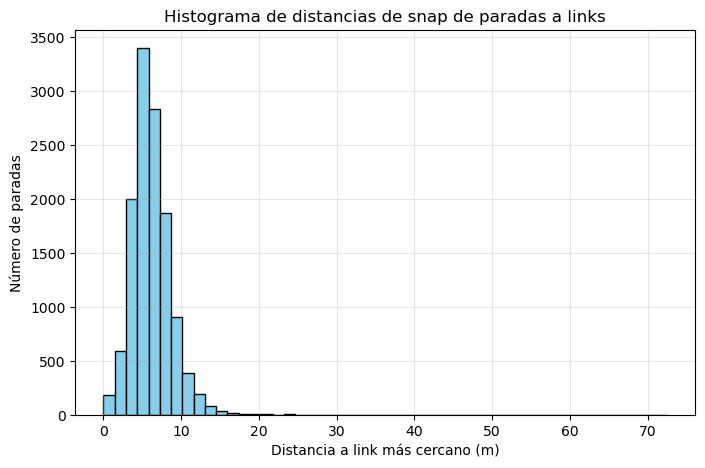

In [ ]:
import matplotlib.pyplot as plt

# Histograma de distancias de snap (en metros)
plt.figure(figsize=(8, 5))
plt.hist(bus_stops_ox["SnapDist_m"], bins=50, color='skyblue', edgecolor='black',)
plt.xlabel("Distancia a link más cercano (m)")
plt.ylabel("Número de paradas")
plt.title("Histograma de distancias de snap de paradas a links")
plt.grid(True, alpha=0.3)
plt.show()

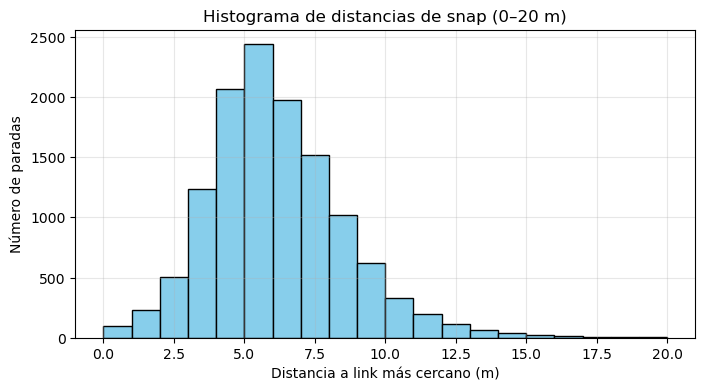

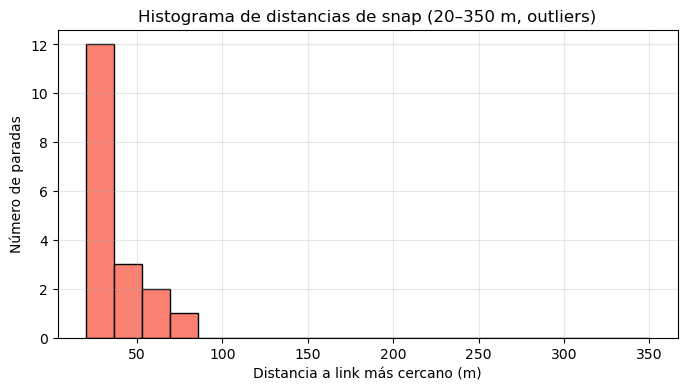

In [54]:
import matplotlib.pyplot as plt

# Histograma para distancias pequeñas (0–20 m)
plt.figure(figsize=(8, 4))
plt.hist(bus_stops_ox["SnapDist_m"], bins=20, color='skyblue', edgecolor='black', range=(0, 20))
plt.xlabel("Distancia a link más cercano (m)")
plt.ylabel("Número de paradas")
plt.title("Histograma de distancias de snap (0–20 m)")
plt.grid(True, alpha=0.3)
plt.show()

# Histograma para outliers (20–350 m)
plt.figure(figsize=(8, 4))
plt.hist(bus_stops_ox["SnapDist_m"], bins=20, color='salmon', edgecolor='black', range=(20, 350))
plt.xlabel("Distancia a link más cercano (m)")
plt.ylabel("Número de paradas")
plt.title("Histograma de distancias de snap (20–350 m, outliers)")
plt.grid(True, alpha=0.3)
plt.show()

## __Remove outliers from Bus Stops to get the STATS__

In [23]:
bus_stops_noOutliers = snapped_bus_stops[snapped_bus_stops["SnapDist_m"] <= 20]
distance_mean = bus_stops_noOutliers["SnapDist_m"].mean()
distance_std = bus_stops_noOutliers["SnapDist_m"].std()
distance_var = bus_stops_noOutliers["SnapDist_m"].var()

print(f"Distancia media (sin outliers): {distance_mean:.2f} m")
print(f"Desviación estándar (sin outliers): {distance_std:.2f} m")
print(f"Varianza (sin outliers): {distance_var:.2f} m")

Distancia media (sin outliers): 6.10 m
Desviación estándar (sin outliers): 2.40 m
Varianza (sin outliers): 5.78 m


## __Get a threshold__

In [38]:
# con 3 veces sigma habia varios que se quedaban fuera porque verdaderamente su nearest link estaba a ej. 14.58
threshold = distance_mean + 4 * distance_std
threshold

np.float64(15.71291059364513)

## __For every Bus Stop, look for links within that Threshold__

In [26]:
# Nodes & Edges de G_snap (en metros)
nodes_Gsnap = gpd.read_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Red Base Snap/Nodes/meters/nodes_snap_m.shp')
edges_Gsnap = gpd.read_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Red Base Snap/Edges/meters/edges_snap_m.shp')

In [31]:
edges_Gsnap['highway'].value_counts()

highway
residential                         268213
service                              70245
tertiary                             27855
unclassified                         14092
secondary                            10088
primary                               7614
trunk                                 1414
primary_link                           777
tertiary_link                          735
trunk_link                             554
secondary_link                         508
motorway_link                          487
motorway                               371
['residential', 'living_street']       195
['residential', 'track']               132
['residential', 'service']              74
['service', 'track']                    50
['unclassified', 'track']               38
['residential', 'tertiary']             37
['residential', 'unclassified']         24
['unclassified', 'service']              8
['living_street', 'service']             8
['tertiary', 'trunk_link']               7
['u

In [42]:
import ast

def parse_highway(val):
    if isinstance(val, str) and val.startswith('['):
        try:
            return ast.literal_eval(val)
        except Exception:
            return val
    return val

edges_Gsnap['highway'] = edges_Gsnap['highway'].apply(parse_highway)

In [43]:
link_hierarchy = [
    'motorway', 'motorway_link',
    'trunk', 'trunk_link',
    'primary', 'primary_link',
    'secondary', 'secondary_link',
    'tertiary', 'tertiary_link',
    'unclassified',
    'residential',
    'service'
]
nearest_link_id = []
nearest_u = []
nearest_v = []

for stop in snapped_bus_stops.itertuples():
    bus_stop_buffer = stop.geometry.buffer(threshold) #13.3
    candidate_edges = edges_Gsnap[
        edges_Gsnap.geometry.intersects(bus_stop_buffer)
    ]
    
    selected_edge = None

    for highway_type in link_hierarchy:
        # Busca edges donde 'highway' sea igual o contenga hwy_type
        mask = candidate_edges['highway'].apply(
            lambda h: highway_type in h if isinstance(h, list) else highway_type == h
        )
        filtered_edges = candidate_edges[mask]
        if not filtered_edges.empty:
            selected_edge = filtered_edges.iloc[0]  # Selecciona el primer edge que cumpla la condición
            break

    if selected_edge is not None:
        nearest_link_id.append(selected_edge['osmid'])
        nearest_u.append(selected_edge['u'])
        nearest_v.append(selected_edge['v'])
    else:
        print(f"STOP {stop.id} sin match. Candidates:")
        for h in candidate_edges['highway']:
            print(f"  {h!r} (type: {type(h)})")
        nearest_link_id.append(None)
        nearest_u.append(None)
        nearest_v.append(None)

    #print(f"Parada ID: {stop.id}, # of candidate links: {len(candidate_edges)}")

snapped_bus_stops['NearestID'] = nearest_link_id
snapped_bus_stops['NearestU'] = nearest_u
snapped_bus_stops['NearestV'] = nearest_v


STOP 201.0 sin match. Candidates:
STOP 503.0 sin match. Candidates:
STOP 569.0 sin match. Candidates:
STOP 1403.0 sin match. Candidates:
STOP 1408.0 sin match. Candidates:
STOP 1411.0 sin match. Candidates:
STOP 1415.0 sin match. Candidates:
STOP 1425.0 sin match. Candidates:
STOP 1426.0 sin match. Candidates:
STOP 1582.0 sin match. Candidates:
STOP 1592.0 sin match. Candidates:
STOP 1600.0 sin match. Candidates:
STOP 1885.0 sin match. Candidates:
STOP 1998.0 sin match. Candidates:
STOP 2031.0 sin match. Candidates:
STOP 2033.0 sin match. Candidates:
STOP 2034.0 sin match. Candidates:
STOP 2197.0 sin match. Candidates:
STOP 2322.0 sin match. Candidates:
STOP 2323.0 sin match. Candidates:
STOP 2345.0 sin match. Candidates:
STOP 2346.0 sin match. Candidates:
STOP 2359.0 sin match. Candidates:
STOP 2361.0 sin match. Candidates:
STOP 2523.0 sin match. Candidates:
STOP 2542.0 sin match. Candidates:
STOP 2852.0 sin match. Candidates:
STOP 4602.0 sin match. Candidates:
STOP 5424.0 sin match. 

In [44]:
snapped_bus_stops.to_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Transporte Publico/SP buffer_hierarchy/bus_stops_newAlg.shp')

In [2]:
SP_snapped_preVisum = gpd.read_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Transporte Publico/SP buffer_hierarchy/bus_stops_newAlg.shp')
SP_snapped_postVisum = gpd.read_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Visum Objects/Bus Stops Snapped to Visum Link/bus_stops_snapped.shp')


In [3]:
SP_snapped_preVisum

,id,mobiliario,iluminaci,señal_ver,señal_hor,banqueta,vegetació,ruta_1,ruta_2,ruta_3,...,SnapDist_m,NearestLin,RelPosOnLi,FromNodeNo,ToNodeNo,NearestL_1,NearestID,NearestU,NearestV,geometry
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Troncal 13A Solidaridad,Troncal 13B Solidaridad,T13A-C02,...,8.207127,9238,0.0,3304,30379,secondary,702909567,1.771859e+09,8.778745e+09,POINT (680976.456 2272736.641)
1,2.0,0.0,0.0,0.0,0.0,0.0,0.0,Troncal 19 Periferico,C19,C46-V1,...,8.441228,4352,1.0,1495,2340,primary,676886947,1.677124e+09,1.700485e+09,POINT (681483.254 2280845.501)
2,3.0,0.0,1.0,0.0,0.0,1.0,0.0,T21 Zapotlanejo,T21-C01,R1-Tepetates,...,6.982640,65242,1.0,24808,24811,residential,905283410,8.407045e+09,8.407045e+09,POINT (700561.553 2281164.022)
3,4.0,0.0,1.0,0.0,0.0,1.0,0.0,T21 Zapotlanejo,T21-C01,R1-Tepetates,...,10.527186,8267,0.0,2947,30220,secondary,188992283,1.746083e+09,8.778413e+09,POINT (700707.084 2281320.114)
4,5.0,0.0,1.0,0.0,0.0,1.0,0.0,T21 Zapotlanejo,T21-C01,R1-Tepetates,...,4.600218,8384,1.0,2997,2948,secondary,162787481,1.746090e+09,1.746083e+09,POINT (700907.289 2281378.235)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12513,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,...,8.663037,49413,0.0,18239,18245,primary,937370922,6.322033e+09,6.322033e+09,POINT (699396.25 2280168.108)
12514,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,...,1.691836,49451,0.0,18255,25555,primary,937343585,6.322039e+09,8.414023e+09,POINT (699836.994 2280555.417)
12515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,...,2.215223,8288,1.0,2957,2959,secondary,238377764,1.746083e+09,1.746083e+09,POINT (701461.661 2281478.528)
12516,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,...,5.281715,8511,1.0,3047,3072,tertiary,162787504,1.746195e+09,1.746294e+09,POINT (701108.581 2281835.306)


In [7]:
SP_snapped_postVisum.rename(columns={'Nearest_L1': 'NearestL_1'}, inplace=True)

In [8]:
SP_snapped_postVisum

,id,mobiliario,iluminaci,señal_ver,señal_hor,banqueta,vegetació,ruta_1,ruta_2,ruta_3,...,YCoord,NearestEdg,SnapDist_m,FromNodeNo,ToNodeNo,NearestLin,RelPosOnLi,NearestL_1,RelPos_New,geometry
0,5946.0,0.0,0.0,0.0,0.0,0.0,0.0,T13A-C01,ATQ-IXT,Caj-SJuan,...,2.262868e+06,"(9.0, 19477.0, 17.0)",5.985804,9.0,19477.0,17.0,0.015488,['primary'],0.100000,POINT (682408.249 2262867.758)
1,5944.0,0.0,0.0,0.0,0.0,0.0,0.0,T13A-C01,Caj-SJuan,N/A,...,2.262784e+06,"(9.0, 19477.0, 17.0)",4.376964,9.0,19477.0,17.0,0.890794,['primary'],0.552000,POINT (682351.394 2262784.143)
2,4523.0,0.0,0.0,0.0,0.0,1.0,0.0,Troncal 13C Solidaridad,T13C-C01,T13C-C02,...,2.275921e+06,"(14.0, 25112.0, 29.0)",5.370930,14.0,25112.0,29.0,0.699219,['secondary'],0.699219,POINT (688847.574 2275920.542)
3,4652.0,1.0,1.0,0.0,0.0,1.0,0.0,Troncal 13C Solidaridad,T13C-C02,T13C-C03,...,2.273817e+06,"(30532.0, 15.0, 31.0)",7.816146,30532.0,15.0,31.0,0.812254,['secondary'],0.812254,POINT (689300.971 2273816.689)
4,7817.0,1.0,0.0,0.0,0.0,0.0,0.0,Troncal 13C Solidaridad,T13C-C02,T13C-C03,...,2.273839e+06,"(17478.0, 15.0, 34.0)",8.525980,17478.0,15.0,34.0,0.971437,['residential'],0.900000,POINT (689281.127 2273838.537)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12513,6024.0,0.0,0.0,0.0,0.0,0.0,0.0,C125-V1,C125-V2,N/A,...,2.262164e+06,"(209176.0, 83364.0, 496646.0)",2.088312,209176.0,83364.0,496646.0,0.909114,['residential'],0.900000,POINT (665560.567 2262163.967)
12514,6084.0,0.0,0.0,0.0,0.0,0.0,0.0,C09,C127,N/A,...,2.270516e+06,"(209505.0, 94404.0, 496975.0)",0.431684,209505.0,94404.0,496975.0,0.779113,['residential'],0.779113,POINT (661682.45 2270516.369)
12515,7229.0,1.0,1.0,0.0,0.0,1.0,1.0,Troncal 11 Río Nilo Guadalupe,C66,N/A,...,2.285177e+06,"(209819.0, 105954.0, 497289.0)",7.369992,209819.0,105954.0,497289.0,0.158390,['service'],0.158390,POINT (664310.591 2285176.886)
12516,2154.0,0.0,0.0,0.0,0.0,0.0,0.0,C73,N/A,N/A,...,2.293268e+06,"(211569.0, 187034.0, 499039.0)",2.409490,211569.0,187034.0,499039.0,0.445711,['residential'],0.445711,POINT (673408.252 2293268.396)


In [17]:
merged = SP_snapped_preVisum.merge(SP_snapped_postVisum, on='NearestLin', suffixes=('_df1', '_df2'))
diff = merged[
    (merged['id_df1'] != merged['id_df2'])
    #(merged['FromNodeNo_df1'] != merged['FromNodeNo_df2']) |
    #(merged['ToNodeNo_df1'] != merged['ToNodeNo_df2'])
]


In [18]:
diff

,id_df1,mobiliario_df1,iluminaci_df1,señal_ver_df1,señal_hor_df1,banqueta_df1,vegetació_df1,ruta_1_df1,ruta_2_df1,ruta_3_df1,...,XCoord_df2,YCoord_df2,NearestEdg_df2,SnapDist_m_df2,FromNodeNo_df2,ToNodeNo_df2,RelPosOnLi_df2,NearestL_1_df2,RelPos_New,geometry_df2
5,4.0,0.0,1.0,0.0,0.0,1.0,0.0,T21 Zapotlanejo,T21-C01,R1-Tepetates,...,700684.851095,2.281323e+06,"(2947.0, 30220.0, 8267.0)",7.650486,2947.0,30220.0,0.827317,['secondary'],0.552000,POINT (700684.851 2281323.323)
9,8.0,0.0,0.0,0.0,0.0,0.0,0.0,C93,Zapo-Tet,N/A,...,690818.320727,2.288646e+06,"(34108.0, 37223.0, 87023.0)",8.194815,34108.0,37223.0,0.020066,['tertiary'],0.552000,POINT (690818.321 2288645.886)
43,56.0,0.0,0.0,0.0,0.0,0.0,0.0,C93,Zapo-Tet,N/A,...,691644.973091,2.290607e+06,"(36053.0, 35488.0, 90400.0)",3.897562,36053.0,35488.0,0.714348,['tertiary'],0.552000,POINT (691644.973 2290606.96)
60,80.0,0.0,1.0,0.0,1.0,0.0,0.0,Troncal 04 Lazara Cardenas,Troncal 10 Mariano Otero,T10-C02,...,662189.376740,2.282015e+06,"(38185.0, 51852.0, 96397.0)",13.010988,38185.0,51852.0,0.883636,['tertiary'],0.552000,POINT (662189.377 2282014.949)
75,99.0,1.0,1.0,1.0,1.0,1.0,0.0,Troncal 09 Circunvalacion,Troncal 11 Río Nilo Guadalupe,C 06,...,674188.986265,2.284968e+06,"(104873.0, 92522.0, 233705.0)",8.301503,104873.0,92522.0,0.155024,['secondary'],0.100000,POINT (674188.986 2284967.853)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,...,699396.250113,2.280168e+06,"(18239.0, 18245.0, 49413.0)",10.040549,18239.0,18245.0,0.108508,['primary'],0.108508,POINT (699396.25 2280168.108)
10028,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,...,699836.994172,2.280555e+06,"(18255.0, 25555.0, 49451.0)",0.302038,18255.0,25555.0,0.928980,['primary'],0.900000,POINT (699836.994 2280555.417)
10029,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,...,701461.660841,2.281479e+06,"(2957.0, 2959.0, 8288.0)",2.373914,2957.0,2959.0,0.791024,['secondary'],0.791024,POINT (701461.661 2281478.528)
10030,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,...,701108.581247,2.281835e+06,"(3047.0, 3072.0, 8511.0)",7.931644,3047.0,3072.0,0.824228,['tertiary'],0.824228,POINT (701108.581 2281835.306)
